In [1]:
# Import Of Required libraries or install libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from statsmodels.tsa.arima.model import ARIMA
import joblib

In [2]:
df = pd.read_csv("C:\\Users\\prust\\OneDrive\\Desktop\\Infosys Springboard\\feature_engineered_dataset.csv")
df.head()

,time_stamp,region,service_type,usage_units,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact,...,rolling_std_3,rolling_std_6,capacity_utilization,growth_rate_1,growth_rate_4,spike_flag,region_East Us,region_Southeast Asia,region_West Europe,service_Storage
0,2021-05-01,Central India,Compute,852.50,929.99,102.30,97.88,97.03,92.14,0,...,14.711418,45.315538,0.916677,0.004122,0.068791,0,False,False,False,False
1,2021-05-15,Central India,Compute,822.77,869.71,98.73,97.56,97.63,92.43,0,...,16.248773,20.091600,0.946028,-0.034874,-0.000644,0,False,False,False,False
2,2021-06-01,Central India,Compute,854.46,928.97,102.54,98.32,97.54,93.10,1,...,17.757489,15.541441,0.919793,0.038516,0.035144,0,False,False,False,False
3,2021-06-15,Central India,Compute,838.37,892.28,100.60,98.98,97.56,93.50,1,...,15.845631,13.831053,0.939582,-0.018831,-0.012521,0,False,False,False,False
4,2021-07-01,Central India,Compute,871.84,921.87,104.62,99.83,97.44,94.03,1,...,16.739143,16.495270,0.945730,0.039923,0.022686,0,False,False,False,False


In [3]:
df.rename(columns={'time_stamp':'timestamp'}, inplace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df = df.reset_index(drop=True)

In [4]:
df.head()

,timestamp,region,service_type,usage_units,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact,...,rolling_std_3,rolling_std_6,capacity_utilization,growth_rate_1,growth_rate_4,spike_flag,region_East Us,region_Southeast Asia,region_West Europe,service_Storage
0,2021-04-01,East Us,Compute,743.820,844.32,89.26,97.91,96.48,91.80,0,...,37.452389,31.676592,0.880969,0.103902,0.144145,0,True,False,False,False
1,2021-04-15,East Us,Compute,692.760,788.18,83.13,99.17,96.16,92.52,0,...,36.211477,31.275538,0.878936,-0.068646,0.022750,0,True,False,False,False
2,2021-05-01,Central India,Compute,852.500,929.99,102.30,97.88,97.03,92.14,0,...,14.711418,45.315538,0.916677,0.004122,0.068791,0,False,False,False,False
3,2021-05-01,East Us,Compute,572.445,764.91,82.52,97.62,97.03,92.14,0,...,87.988838,56.015864,0.748382,-0.173675,-0.165228,0,True,False,False,False
4,2021-05-01,Central India,Storage,665.320,715.23,53.23,99.22,97.03,92.14,0,...,7.684012,33.656524,0.930218,0.021322,0.077494,0,False,False,False,True


In [5]:
target = "usage_units"

In [6]:
# Spliting the time series
split_index = int(len(df) * 0.8)

train = df[:split_index]
test = df[split_index:]

In [7]:
train_series = train[target]
test_series = test[target]

In [8]:
# Train The ARIMA Model
arima_model = ARIMA(train_series, order=(2,1,2))
arima_model_fit = arima_model.fit()
arima_pred = arima_model_fit.forecast(steps=len(test_series))

In [9]:
# Evaluation Of ARIMA Model
arima_mae = mean_absolute_error(test_series, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_pred))
arima_r2 = r2_score(test_series, arima_pred)
print("ARIMA Performance")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)
print("R2:", arima_r2)

ARIMA Performance
MAE: 122.69814778970127
RMSE: 160.65168025490198
R2: -0.23604309819250302


In [10]:
df = pd.get_dummies(df, columns=['region', 'service_type'])

In [11]:
# Drop The timestamp column
target = "usage_units"

X = df.drop(columns=[target, "timestamp"], errors="ignore")
y = df[target]

In [12]:
# Again Spliting the time series 
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [13]:
X_train = X_train.drop(columns=["timestamp"], errors="ignore")
X_test = X_test.drop(columns=["timestamp"], errors="ignore")

In [14]:
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

In [15]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [16]:
print(X_train.dtypes)

provisioned_capacity        float64
cost_usd                    float64
availability_pct            float64
economic_indicator_index    float64
market_demand_index         float64
product_launch_impact       float64
year                        float64
month                       float64
quarter                     float64
week_of_year                float64
is_month_start              float64
is_month_end                float64
lag_1                       float64
lag_2                       float64
lag_4                       float64
lag_8                       float64
rolling_mean_3              float64
rolling_mean_6              float64
rolling_std_3               float64
rolling_std_6               float64
capacity_utilization        float64
growth_rate_1               float64
growth_rate_4               float64
spike_flag                  float64
region_East Us              float64
region_Southeast Asia       float64
region_West Europe          float64
service_Storage             

In [17]:
# Train the  XGBoost Model
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [18]:
xgb_pred = xgb_model.predict(X_test)

In [19]:
# Evaluation Of XGBoost Model
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
print("XGBoost Performance")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost Performance
MAE: 31.269480523003466
RMSE: 53.11921680855106
R2: 0.8648654512157264


In [20]:
data_lstm = df[['usage_units']]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_lstm)

In [21]:
sequence_length = 8
X = []
y = []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])
X = np.array(X)
y = np.array(y)

In [22]:
# Again Spliting the time series 
split = int(0.8 * len(X))

X_train_lstm = X[:split]
X_test_lstm = X[split:]

y_train_lstm = y[:split]
y_test_lstm = y[split:]

In [23]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], 1)))
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mse'
)
model.summary()

C:\Users\prust\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Trainig the LSTM Model
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=16,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.1017 - val_loss: 0.1150
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0387 - val_loss: 0.0410
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0330 - val_loss: 0.0523
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0329 - val_loss: 0.0473
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0324 - val_loss: 0.0466
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0324 - val_loss: 0.0456
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0323 - val_loss: 0.0467
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0323 - val_loss: 0.0450
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0322 - val_loss: 0.0478
Epoch 10/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0323 - val_loss: 0.0489
Epoch 11/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0322 - val_loss: 0.0472
Epoch 12/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

In [25]:
# Prediction of LSTM Model
lstm_pred = model.predict(X_test_lstm)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_lstm_actual = scaler.inverse_transform(y_test_lstm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step


In [26]:
# Evaluation of LSTM Model
lstm_mae = mean_absolute_error(y_test_lstm_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm_actual, lstm_pred))
lstm_r2 = r2_score(y_test_lstm_actual, lstm_pred)

print("LSTM Performance")
print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)
print("R2:", lstm_r2)

LSTM Performance
MAE: 126.0253472309728
RMSE: 163.55893099909036
R2: -0.2657368020811137


In [27]:
# Comparison Between ARIMA , XGBoost model And LSTM Model
# ARIMA VS XGDBOOST VS LSTM
comparison = pd.DataFrame({
    "Model": ["ARIMA", "XGBoost", "LSTM"],
    "MAE": [arima_mae, xgb_mae, lstm_mae],
    "RMSE": [arima_rmse, xgb_rmse, lstm_rmse],
    "R2": [arima_r2, xgb_r2, lstm_r2]
})

print(comparison)

     Model         MAE        RMSE        R2
0    ARIMA  122.698148  160.651680 -0.236043
1  XGBoost   31.269481   53.119217  0.864865
2     LSTM  126.025347  163.558931 -0.265737


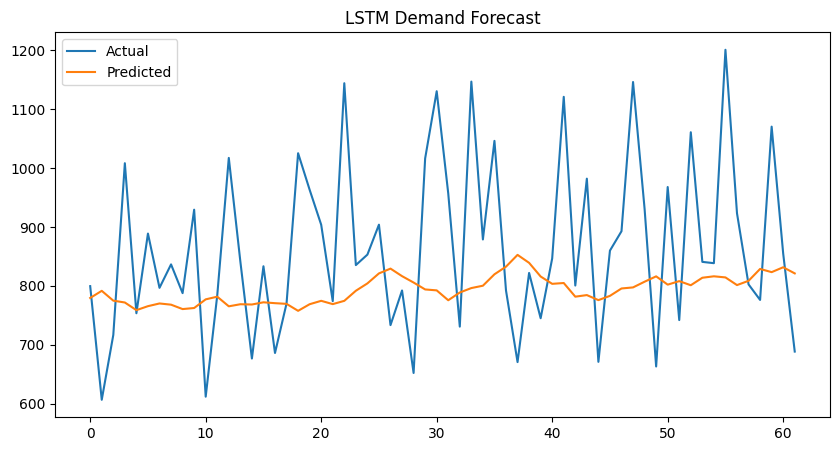

In [28]:
#  Actual VS Prediction on Visualization 
plt.figure(figsize=(10,5))
plt.plot(y_test_lstm_actual, label="Actual")
plt.plot(lstm_pred, label="Predicted")
plt.legend()
plt.title("LSTM Demand Forecast")
plt.show()

In [29]:
# Hypoparameter Tunning 
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4,6,8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


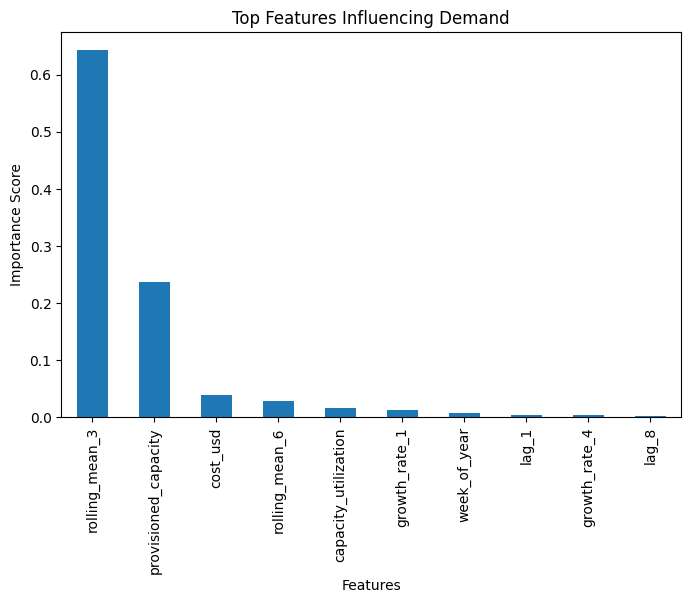

In [30]:
#  Feature Importance Analysis
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)
importance.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top Features Influencing Demand")
plt.ylabel("Importance Score")
plt.xlabel("Features")

plt.show()

In [31]:
# Selecting The Best Model
if xgb_mae < arima_mae and xgb_mae < lstm_mae:
    final_model = best_model
    print("XGBoost selected as final model")

elif arima_mae < xgb_mae and arima_mae < lstm_mae:
    final_model = arima_model_fit
    print("ARIMA selected as final model")

else:
    final_model = model
    print("LSTM selected as final model")

XGBoost selected as final model


In [32]:
# Saving the Best model
joblib.dump(final_model, "demand_forecasting_model.pkl")

joblib.dump(list(X_train.columns), "feature_list.pkl")

['feature_list.pkl']

In [33]:
future_prediction = final_model.predict(X_test.iloc[:5])

print("Final Predictions:")
print(future_prediction)

Final Predictions:
[ 947.6198   803.0036   601.33966  703.7577  1012.66   ]
